# Full TF-nnPU vs Dynamic GAT-LSTM comparison — original prefix-level split

This notebook performs the **entire clean + label-noise comparison** using the same supervised split style as your original TF notebook:

\[
\boxed{\text{generate temporal samples first} \rightarrow \text{random 80/20 split}}
\]

with `torch.manual_seed(42)`.

Therefore, prefixes/windows from the same physical scene can occur in both training and validation. This is intentional here because you want to determine whether that split explains the higher performance of the original TF-nnPU experiment.

## Models

The notebook trains:

1. **TF-nnPU** — your exact Transformer architecture and exact nnPU loss.
2. **Dynamic GAT-LSTM-BCE** — adapted external architecture with BCE.
3. **Dynamic GAT-LSTM-nnPU** — same GAT-LSTM architecture, but using your exact nnPU loss.

## Fairness controls

All three models use:

- the same QCar scenes;
- the same common endpoints \(t=4,\ldots,15\);
- the same sample-level 80/20 split indices;
- the same clean evaluation label \(s_t\);
- the exact same corrupted training samples for each noise condition.

Noise conditions:

- clean;
- symmetric \(0\leftrightarrow1\): 5%, 10%, 15%, 20%;
- asymmetric \(P\rightarrow U\): 5%, 10%, 15%, 20%.

## Important

This notebook is suitable for **diagnosing and comparing under your original split behavior**. If scene overlap inflates performance, the resulting validation numbers should not be presented as unseen-scene generalization without clearly describing the sample-level split.

In [3]:
# ============================================================
# 1. Imports / configuration
# ============================================================

import os
import math
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
)

import matplotlib.pyplot as plt

try:
    from scipy.stats import wilcoxon
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# Same endpoint set for every model:
# frame_id 3 = 4 observed frames; frame_id 14 = 15 observed frames
MIN_ENDPOINT = 3
MAX_ENDPOINT = 14

N_OUTER_FOLDS = 5
INNER_VAL_FRACTION = 0.15

# Exact Stage-1 hyperparameters from your uploaded notebook
AE_EPOCHS = 20
AE_BATCH_SIZE = 16
AE_LR = 1e-3
AE_WEIGHT_DECAY = 1e-4

# Exact Stage-2 hyperparameters from your uploaded notebook
CLF_EPOCHS = 200
CLF_BATCH_SIZE = 32
CLF_LR = 1e-4
CLF_WEIGHT_DECAY = 1e-4
EARLY_STOP_PATIENCE = 8
EARLY_STOP_MIN_DELTA = 1e-3

POS_PRIOR = 0.10

NOISE_CONDITIONS = [
    ("none", 0.00),
    ("symmetric", 0.05),
    ("symmetric", 0.10),
    ("symmetric", 0.15),
    ("symmetric", 0.20),
    ("p_to_u", 0.05),
    ("p_to_u", 0.10),
    ("p_to_u", 0.15),
    ("p_to_u", 0.20),
]

Using device: cuda


## Exact data-loading functions from your model notebook

In [4]:
def load_mix_txt(path: str) -> np.ndarray:
    """Load TXT file with columns:
    0: time/frame index
    1: distance
    2: angle
    3: sin(yaw)
    4: cos(yaw)
    5: speed
    6: frame-level label (0 = safe, 1 = collision)
    7: sequence_id
    """
    data = np.loadtxt(path)
    if data.ndim == 1:
        data = data[None, :]  # ensure 2D
    return data


def group_sequences_with_frame_labels(data: np.ndarray):
    """Group flat data by sequence_id and sort by time.

    Returns:
        sequences: list of arrays, each of shape (T_i, 5) with features
                   [distance, angle, sin(yaw), cos(yaw), speed]
        frame_labels: list of arrays, each of shape (T_i,) with 0/1 labels
        seq_ids: list of sequence ids
    """
    seq_col = data[:, 7].astype(int)
    time_col = data[:, 0]
    unique_ids = np.unique(seq_col)

    sequences = []
    frame_labels = []
    seq_ids = []

    for sid in unique_ids:
        mask = (seq_col == sid)
        seq_data = data[mask]
        # sort by time
        order = np.argsort(seq_data[:, 0])
        seq_data = seq_data[order]

        # features: columns 1..5
        X = seq_data[:, 1:6].astype(np.float32)
        y = seq_data[:, 6].astype(np.float32)

        sequences.append(X)
        frame_labels.append(y)
        seq_ids.append(int(sid))

    return sequences, frame_labels, seq_ids

## Exact padding utilities from your model notebook

In [5]:
def pad_collate_unsupervised(batch):
    """Collate function for UnsupervisedSeqDataset.

    Args:
        batch: list of tensors [T_i, F]

    Returns:
        padded: (B, T_max, F)
        pad_mask: (B, T_max) bool, True where padding
    """
    lengths = [x.shape[0] for x in batch]
    padded = pad_sequence(batch, batch_first=True)  # (B, T_max, F)
    T_max = padded.shape[1]

    # pad_mask: True where positions are padding
    idxs = torch.arange(T_max).unsqueeze(0).expand(len(lengths), -1)
    lengths_tensor = torch.tensor(lengths).unsqueeze(1)
    pad_mask = idxs >= lengths_tensor

    return padded, pad_mask


def pad_collate_supervised(batch):
    """Collate function for supervised prefix dataset.

    Args:
        batch: list of (tensor[T_i, F], label)

    Returns:
        padded: (B, T_max, F)
        labels: (B,)
        pad_mask: (B, T_max) bool
    """
    seqs, labels = zip(*batch)
    lengths = [x.shape[0] for x in seqs]
    padded = pad_sequence(seqs, batch_first=True)  # (B, T_max, F)
    T_max = padded.shape[1]

    idxs = torch.arange(T_max).unsqueeze(0).expand(len(lengths), -1)
    lengths_tensor = torch.tensor(lengths).unsqueeze(1)
    pad_mask = idxs >= lengths_tensor

    labels = torch.stack(labels)  # (B,)
    return padded, labels, pad_mask

## Exact `TemporalEncoder` from your model notebook

In [6]:
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding for sequences with batch_first=True.

    Expects input of shape (B, T, D).
    """
    def __init__(self, d_model: int, max_len: int = 500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer("pe", pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, T, D)
        T = x.size(1)
        x = x + self.pe[:, :T, :]
        return x


class TemporalEncoder(nn.Module):
    """Shared temporal encoder: input_dim -> d_model via TransformerEncoder."""
    def __init__(
        self,
        input_dim: int = 5,
        d_model: int = 64,
        nhead: int = 4,
        num_layers: int = 2,
        dim_feedforward: int = 128,
        dropout: float = 0.1,
        max_len: int = 500,
    ):
        super().__init__()
        self.input_dim = input_dim
        self.d_model = d_model

        self.in_proj = nn.Linear(input_dim, d_model)
        self.pos = PositionalEncoding(d_model, max_len=max_len)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    def forward(self, x: torch.Tensor, pad_mask: torch.Tensor = None) -> torch.Tensor:
        """Forward pass.

        Args:
            x: (B, T, input_dim)
            pad_mask: (B, T) bool, True where padding

        Returns:
            h: (B, T, d_model)
        """
        h = self.in_proj(x)
        h = self.pos(h)
        h = self.encoder(h, src_key_padding_mask=pad_mask)
        return h

## Exact `TemporalAutoencoder` from your model notebook

In [7]:
class TemporalAutoencoder(nn.Module):
    """Temporal autoencoder: encoder + linear decoder back to input_dim."""
    def __init__(self, encoder: TemporalEncoder):
        super().__init__()
        self.encoder = encoder
        self.out_proj = nn.Linear(encoder.d_model, encoder.input_dim)

    def forward(self, x: torch.Tensor, pad_mask: torch.Tensor = None) -> torch.Tensor:
        """Reconstruct the input sequence.

        Args:
            x: (B, T, input_dim)
            pad_mask: (B, T) bool

        Returns:
            x_hat: (B, T, input_dim)
        """
        h = self.encoder(x, pad_mask=pad_mask)
        x_hat = self.out_proj(h)
        return x_hat

## Exact `TemporalRiskTransformer` from your model notebook

In [8]:
class TemporalRiskTransformer(nn.Module):
    """Transformer encoder + masked attention pooling -> sequence-level logit.

    Uses a pretrained TemporalEncoder and a small MLP head.
    """
    def __init__(self, encoder: TemporalEncoder, d_hidden: int = 64, dropout: float = 0.1):
        super().__init__()
        self.encoder = encoder

        d_model = encoder.d_model

        # Attention pooling over time
        self.pool = nn.Linear(d_model, 1)

        # Classification head
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_hidden, 1),
        )

    def forward(self, x: torch.Tensor, pad_mask: torch.Tensor = None):
        """Forward pass.

        Args:
            x: (B, T, input_dim)
            pad_mask: (B, T) bool

        Returns:
            logits: (B,) raw logits for collision probability
            z_seq: (B, d_model) pooled sequence representation
        """
        h = self.encoder(x, pad_mask=pad_mask)  # (B, T, d_model)

        # Attention logits over time
        att_logits = self.pool(h).squeeze(-1)  # (B, T)

        if pad_mask is not None:
            att_logits = att_logits.masked_fill(pad_mask, float("-inf"))

        att_weights = F.softmax(att_logits, dim=1)  # (B, T)

        # Weighted sum
        z_seq = torch.sum(h * att_weights.unsqueeze(-1), dim=1)  # (B, d_model)

        logits = self.head(z_seq).squeeze(-1)  # (B,)
        return logits, z_seq

## Exact nnPU loss from your model notebook

In [9]:
# === nnPU (Positive–Unlabeled) loss for collision (positive) vs safe (unlabeled) ===
import torch.nn.functional as F

def nnpu_loss(
    logits: torch.Tensor,
    targets: torch.Tensor,
    prior: float,
    gamma: float = 1.0,
    beta: float = 0.0,
) -> torch.Tensor:
    # nnPU loss (non-negative PU) with logistic loss.
    #
    # logits: (B,)
    # targets: (B,) in {0, 1}, where:
    #     1 = positive (collision)
    #     0 = unlabeled (safe / mixture)
    #
    # prior: π_p, estimated positive prior (collision prior) in the training set.
    # gamma, beta: hyperparameters controlling how aggressively to handle negative risk.

    # Ensure float
    y = targets.float()
    logits = logits.view(-1)

    # Masks
    pos_mask = (y == 1)
    unl_mask = (y == 0)

    # Logistic loss for y=+1 and y=-1
    # l(f, +1) = log(1 + exp(-f)) = softplus(-f)
    # l(f, -1) = log(1 + exp(f))  = softplus(f)
    def loss_pos(z):
        return F.softplus(-z)

    def loss_neg(z):
        return F.softplus(z)

    device = logits.device

    if pos_mask.any():
        pos_logits = logits[pos_mask]
        L_p_pos = loss_pos(pos_logits).mean()          # E_p[l(f, +1)]
        L_p_neg = loss_neg(pos_logits).mean()          # E_p[l(f, -1)]
    else:
        # No positive examples in this batch; set to zero
        L_p_pos = torch.tensor(0.0, device=device)
        L_p_neg = torch.tensor(0.0, device=device)

    if unl_mask.any():
        unl_logits = logits[unl_mask]
        L_u_neg = loss_neg(unl_logits).mean()          # E_u[l(f, -1)]
    else:
        L_u_neg = torch.tensor(0.0, device=device)

    # Positive risk
    risk_positive = prior * L_p_pos

    # Negative risk estimate
    risk_negative = L_u_neg - prior * L_p_neg

    # Non-negative PU trick
    if risk_negative.item() < -beta:
        # In this regime, flip the sign of the negative risk and scale by gamma
        loss = risk_positive - gamma * risk_negative
    else:
        loss = risk_positive + risk_negative

    return loss

def upu_loss(
    logits: torch.Tensor,
    targets: torch.Tensor,
    prior: float,
    gamma: float = 1.0,
    beta: float = 0.0,
) -> torch.Tensor:
    """Unbiased PU (uPU) loss — same as nnPU but WITHOUT non-negative clipping."""

    y = targets.float()
    logits = logits.view(-1)

    pos_mask = (y == 1)
    unl_mask = (y == 0)

    def loss_pos(z):
        return F.softplus(-z)

    def loss_neg(z):
        return F.softplus(z)

    # Positive risk
    if pos_mask.sum() > 0:
        L_p_pos = loss_pos(logits[pos_mask]).mean()
        L_p_neg = loss_neg(logits[pos_mask]).mean()
    else:
        L_p_pos = torch.tensor(0.0, device=logits.device)
        L_p_neg = torch.tensor(0.0, device=logits.device)

    # Unlabeled risk
    if unl_mask.sum() > 0:
        L_u_neg = loss_neg(logits[unl_mask]).mean()
    else:
        L_u_neg = torch.tensor(0.0, device=logits.device)

    risk_positive = prior * L_p_pos
    risk_negative = L_u_neg - prior * L_p_neg  # <-- NO max(0, ...) here

    loss = risk_positive + risk_negative
    return loss

## Exact early-stopping class from your model notebook

In [10]:
import copy
class EarlyStopping:
    def __init__(self, patience=8, min_delta=1e-4, mode="max"):
        """Simple early stopping with best-weight restore.
        mode="max": metric should increase (e.g., AUC)
        mode="min": metric should decrease (e.g., loss)
        """
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.best = -np.inf if mode == "max" else np.inf
        self.num_bad_epochs = 0
        self.best_state = None

    def step(self, metric, model):
        improved = (metric > self.best + self.min_delta) if self.mode == "max" else (metric < self.best - self.min_delta)
        if improved:
            self.best = metric
            self.num_bad_epochs = 0
            self.best_state = copy.deepcopy(model.state_dict())
            return False
        self.num_bad_epochs += 1
        return self.num_bad_epochs >= self.patience

    def restore_best_weights(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

## Verify that the TF model is still exactly 71,746 trainable parameters

In [11]:
# ============================================================
# 9. Verify the copied TF-nnPU architecture
# ============================================================

_exact_encoder = TemporalEncoder(
    input_dim=5,
    d_model=64,
    nhead=4,
    num_layers=2,
    dim_feedforward=128,
    dropout=0.1,
    max_len=500,
)
_exact_tf = TemporalRiskTransformer(encoder=_exact_encoder)

n_params = sum(p.numel() for p in _exact_tf.parameters() if p.requires_grad)

print("TF-nnPU trainable parameters:", f"{n_params:,}")
assert n_params == 71746, (
    f"Expected 71,746 parameters from your original model, got {n_params:,}"
)
print("Architecture verification PASSED: 71,746 trainable parameters.")

TF-nnPU trainable parameters: 71,746
Architecture verification PASSED: 71,746 trainable parameters.


C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [16]:
# ============================================================
# Load QCar dataset
# ============================================================

DATASET_CANDIDATES = [
    Path("safe_col_mix.txt"),
    Path("/mnt/data/safe_col_mix.txt"),
    Path("safe_col_mix.txt"),
    Path("/mnt/data/safe_col_mix.txt"),
]

TXT_PATH = next((p for p in DATASET_CANDIDATES if p.exists()), None)

if TXT_PATH is None:
    raise FileNotFoundError(
        "Dataset not found. Put safe_col_mix(3).txt next to this notebook "
        "or edit DATASET_CANDIDATES."
    )

raw_data = load_mix_txt(str(TXT_PATH))
sequences, frame_labels, seq_ids = group_sequences_with_frame_labels(raw_data)

if any(len(x) != 15 for x in sequences):
    raise ValueError("Expected exactly 15 frames per scene.")

bad = raw_data[
    (raw_data[:, 6] == 1)
    & (raw_data[:, 1] >= 9.0)
]

if len(bad) > 0:
    raise ValueError(
        f"Found {len(bad)} observed positive rows with distance >= 9."
    )

scene_to_X = {
    int(sid): X
    for sid, X in zip(seq_ids, sequences)
}

scene_to_s = {
    int(sid): y.astype(np.float32)
    for sid, y in zip(seq_ids, frame_labels)
}

scene_to_Y = {
    int(sid): int(y.max())
    for sid, y in zip(seq_ids, frame_labels)
}

ALL_SCENES = np.array(
    sorted(scene_to_X.keys()),
    dtype=int,
)

print("=" * 72)
print("DATASET SUMMARY")
print("=" * 72)
print(f"Scenes:                  {len(ALL_SCENES):,}")
print(f"Frames per scene:        15")
print(f"Collision scenes:        {sum(scene_to_Y[s] for s in ALL_SCENES):,}")
print(f"Observed positives P:    {int(raw_data[:,6].sum()):,}")
print(f"Observed positive rate:  {100*raw_data[:,6].mean():.2f}%")
print("=" * 72)

DATASET SUMMARY
Scenes:                  981
Frames per scene:        15
Collision scenes:        371
Observed positives P:    3,424
Observed positive rate:  23.27%


# Common temporal samples and original-like 80/20 split

The GAT-LSTM needs four observations, so the direct comparison uses the common prediction endpoints:

\[
t=4,\ldots,15.
\]

This gives 12 temporal samples per scene.

The Transformer still uses the **complete prefix** at each endpoint. For example, at \(t=10\):

- TF-nnPU sees frames \(1,\ldots,10\);
- GAT-LSTM sees frames \(7,\ldots,10\).

The split is then performed **after these samples are generated**, matching the behavior you wanted to reproduce.

In [17]:
# ============================================================
# Common sample order and prefix-level random split
# ============================================================

from torch.utils.data import Subset, random_split

MIN_ENDPOINT = 3   # fourth frame, zero-based
MAX_ENDPOINT = 14  # fifteenth frame, zero-based

COMMON_KEYS = []
COMMON_CLEAN_S = []

for sid in ALL_SCENES:
    s = scene_to_s[int(sid)]

    for end in range(MIN_ENDPOINT, MAX_ENDPOINT + 1):
        COMMON_KEYS.append((int(sid), int(end)))
        COMMON_CLEAN_S.append(int(s[end]))

COMMON_CLEAN_S = np.asarray(
    COMMON_CLEAN_S,
    dtype=np.int64,
)

N_COMMON = len(COMMON_KEYS)

torch.manual_seed(42)

n_train = int(0.8 * N_COMMON)
n_val = N_COMMON - n_train

idx_dataset = list(range(N_COMMON))

train_subset_idx, val_subset_idx = random_split(
    idx_dataset,
    [n_train, n_val],
)

TRAIN_IDX = np.asarray(
    train_subset_idx.indices,
    dtype=int,
)

VAL_IDX = np.asarray(
    val_subset_idx.indices,
    dtype=int,
)

TRAIN_KEYS = [
    COMMON_KEYS[i]
    for i in TRAIN_IDX
]

VAL_KEYS = [
    COMMON_KEYS[i]
    for i in VAL_IDX
]

train_scenes = {
    sid for sid, end in TRAIN_KEYS
}

val_scenes = {
    sid for sid, end in VAL_KEYS
}

overlap_scenes = (
    train_scenes & val_scenes
)

print("=" * 72)
print("PREFIX-LEVEL RANDOM SPLIT")
print("=" * 72)
print(f"Common samples:            {N_COMMON:,}")
print(f"Train samples:             {len(TRAIN_IDX):,}")
print(f"Validation samples:        {len(VAL_IDX):,}")
print(f"Unique train scenes:       {len(train_scenes):,}")
print(f"Unique validation scenes:  {len(val_scenes):,}")
print(f"Scenes in BOTH:            {len(overlap_scenes):,}")
print(
    f"Validation scene overlap:  "
    f"{100*len(overlap_scenes)/max(1,len(val_scenes)):.2f}%"
)
print("=" * 72)

PREFIX-LEVEL RANDOM SPLIT
Common samples:            11,772
Train samples:             9,417
Validation samples:        2,355
Unique train scenes:       981
Unique validation scenes:  908
Scenes in BOTH:            908
Validation scene overlap:  100.00%


# Shared label-corruption masks

Noise is applied **only to training samples**. Validation labels remain the original clean \(s_t\).

For each condition, one corruption dictionary is created and reused by all three models. Therefore, if `(scene 52, endpoint 9)` is flipped for TF-nnPU, it is also flipped for both GAT-LSTM variants.

In [18]:
# ============================================================
# Noise configuration and common corruption map
# ============================================================

NOISE_CONDITIONS = [
    ("none", 0.00),
    ("symmetric", 0.05),
    ("symmetric", 0.10),
    ("symmetric", 0.15),
    ("symmetric", 0.20),
    ("p_to_u", 0.05),
    ("p_to_u", 0.10),
    ("p_to_u", 0.15),
    ("p_to_u", 0.20),
]


def make_training_noise_map(
    noise_mode,
    noise_rate,
    seed,
):
    clean = COMMON_CLEAN_S[TRAIN_IDX].copy()
    noisy = clean.copy()

    rng = np.random.default_rng(seed)

    p_to_u = 0
    u_to_p = 0

    if noise_mode == "none" or noise_rate == 0:
        pass

    elif noise_mode == "symmetric":
        k = int(round(noise_rate * len(noisy)))
        selected = rng.permutation(len(noisy))[:k]

        before = noisy.copy()
        noisy[selected] = 1 - noisy[selected]

        p_to_u = int(
            np.sum(
                (before == 1)
                & (noisy == 0)
            )
        )

        u_to_p = int(
            np.sum(
                (before == 0)
                & (noisy == 1)
            )
        )

    elif noise_mode == "p_to_u":
        positive_idx = np.where(
            noisy == 1
        )[0]

        k = int(
            round(
                noise_rate
                * len(positive_idx)
            )
        )

        selected = (
            rng.permutation(positive_idx)[:k]
            if k > 0
            else np.asarray([], dtype=int)
        )

        noisy[selected] = 0
        p_to_u = int(k)

    else:
        raise ValueError(
            f"Unknown noise mode: {noise_mode}"
        )

    noise_map = {
        TRAIN_KEYS[j]: int(noisy[j])
        for j in range(len(TRAIN_KEYS))
    }

    stats = {
        "n_train": len(noisy),
        "clean_positive": int(clean.sum()),
        "final_positive": int(noisy.sum()),
        "flipped_total": int(
            np.sum(clean != noisy)
        ),
        "realized_flip_rate": float(
            np.mean(clean != noisy)
        ),
        "p_to_u": p_to_u,
        "u_to_p": u_to_p,
    }

    return noise_map, stats

# TF datasets

The TF input and model are unchanged. The only new metadata is:

- `train_y`: clean or corrupted \(s_t\), used by nnPU;
- `eval_y`: clean \(s_t\), used only for validation metrics;
- scene and endpoint identifiers for alignment.

In [19]:
# ============================================================
# Transformer datasets
# ============================================================

class AllTrajectoryDataset(Dataset):
    """All 15-frame trajectories for original-like Stage-1 pretraining."""
    def __init__(self):
        self.data = [
            torch.tensor(
                scene_to_X[int(sid)],
                dtype=torch.float32,
            )
            for sid in ALL_SCENES
        ]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


class CommonTFDataset(Dataset):
    """All common prefixes in COMMON_KEYS order."""

    def __init__(self, noise_map=None):
        self.items = []

        for sid, end in COMMON_KEYS:
            X = scene_to_X[sid]
            s = scene_to_s[sid]

            clean_s = int(s[end])

            train_y = (
                int(noise_map[(sid, end)])
                if (
                    noise_map is not None
                    and (sid, end) in noise_map
                )
                else clean_s
            )

            prefix = X[
                :end + 1
            ].astype(np.float32)

            self.items.append(
                (
                    torch.tensor(
                        prefix,
                        dtype=torch.float32,
                    ),
                    float(train_y),
                    float(clean_s),
                    int(sid),
                    int(end),
                )
            )

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        X, train_y, eval_y, sid, end = self.items[idx]

        return (
            X,
            torch.tensor(train_y, dtype=torch.float32),
            torch.tensor(eval_y, dtype=torch.float32),
            torch.tensor(sid, dtype=torch.long),
            torch.tensor(end, dtype=torch.long),
        )


def pad_collate_common_tf(batch):
    seqs, train_y, eval_y, scenes, ends = zip(*batch)

    lengths = [
        x.shape[0]
        for x in seqs
    ]

    padded = pad_sequence(
        seqs,
        batch_first=True,
    )

    T_max = padded.shape[1]

    idxs = torch.arange(
        T_max
    ).unsqueeze(0).expand(
        len(lengths),
        -1,
    )

    lengths_tensor = torch.tensor(
        lengths
    ).unsqueeze(1)

    pad_mask = (
        idxs >= lengths_tensor
    )

    return (
        padded,
        torch.stack(train_y),
        torch.stack(eval_y),
        pad_mask,
        torch.stack(scenes),
        torch.stack(ends),
    )

# Transformer Stage 1 — reproduce original exposure

Stage 1 is performed once on **all complete trajectories**, before the supervised random split, matching the exposure behavior of the original notebook.

The exact `TemporalEncoder` and `TemporalAutoencoder` classes remain unchanged.

In [20]:
# ============================================================
# Stage-1 reconstruction pretraining on all scenes
# ============================================================

def pretrain_tf_all_scenes(seed=SEED):
    set_seed(seed)

    encoder = TemporalEncoder(
        input_dim=5,
        d_model=64,
        nhead=4,
        num_layers=2,
        dim_feedforward=128,
        dropout=0.1,
        max_len=500,
    ).to(device)

    ae_model = TemporalAutoencoder(
        encoder
    ).to(device)

    ds = AllTrajectoryDataset()

    loader = DataLoader(
        ds,
        batch_size=AE_BATCH_SIZE,
        shuffle=True,
        collate_fn=pad_collate_unsupervised,
    )

    optimizer = torch.optim.AdamW(
        ae_model.parameters(),
        lr=AE_LR,
        weight_decay=AE_WEIGHT_DECAY,
    )

    criterion = nn.MSELoss()

    for epoch in range(
        1,
        AE_EPOCHS + 1,
    ):
        ae_model.train()

        total_loss = 0.0

        for X, pad_mask in loader:
            X = X.to(device)
            pad_mask = pad_mask.to(device)

            X_hat = ae_model(
                X,
                pad_mask=pad_mask,
            )

            loss = criterion(
                X_hat,
                X,
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        if (
            epoch == 1
            or epoch % 5 == 0
            or epoch == AE_EPOCHS
        ):
            print(
                f"AE epoch {epoch:2d}/{AE_EPOCHS} | "
                f"loss={total_loss/len(loader):.6f}"
            )

    return copy.deepcopy(
        ae_model.encoder.state_dict()
    )


PRETRAINED_TF_STATE = pretrain_tf_all_scenes(
    seed=SEED
)

AE epoch  1/20 | loss=2.552606
AE epoch  5/20 | loss=0.052105
AE epoch 10/20 | loss=0.020426
AE epoch 15/20 | loss=0.010717
AE epoch 20/20 | loss=0.007049


In [21]:
# ============================================================
# TF clean-s evaluation and nnPU training
# ============================================================

@torch.no_grad()
def evaluate_tf_clean_s(
    model,
    loader,
    threshold=0.5,
):
    model.eval()

    all_probs = []
    all_labels = []

    for (
        X,
        train_y,
        eval_y,
        pad_mask,
        scenes,
        ends,
    ) in loader:

        X = X.to(device)
        pad_mask = pad_mask.to(device)

        logits, _ = model(
            X,
            pad_mask=pad_mask,
        )

        probs = torch.sigmoid(
            logits
        ).cpu().numpy()

        all_probs.append(probs)
        all_labels.append(
            eval_y.numpy()
        )

    y_true = np.concatenate(
        all_labels
    ).astype(int)

    y_prob = np.concatenate(
        all_probs
    )

    y_pred = (
        y_prob >= threshold
    ).astype(int)

    return {
        "accuracy": accuracy_score(
            y_true,
            y_pred,
        ),
        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "recall": recall_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
    }


def train_tf_nnpu_prefix_split(
    noise_map,
    prior=POS_PRIOR,
    seed=SEED,
):
    set_seed(seed)

    full_ds = CommonTFDataset(
        noise_map=noise_map
    )

    train_ds = Subset(
        full_ds,
        TRAIN_IDX.tolist(),
    )

    val_ds = Subset(
        full_ds,
        VAL_IDX.tolist(),
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=CLF_BATCH_SIZE,
        shuffle=True,
        collate_fn=pad_collate_common_tf,
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=64,
        shuffle=False,
        collate_fn=pad_collate_common_tf,
    )

    encoder = TemporalEncoder(
        input_dim=5,
        d_model=64,
        nhead=4,
        num_layers=2,
        dim_feedforward=128,
        dropout=0.1,
        max_len=500,
    )

    encoder.load_state_dict(
        PRETRAINED_TF_STATE
    )

    model = TemporalRiskTransformer(
        encoder=encoder
    ).to(device)

    optimizer = torch.optim.AdamW(
        filter(
            lambda p: p.requires_grad,
            model.parameters(),
        ),
        lr=CLF_LR,
        weight_decay=CLF_WEIGHT_DECAY,
    )

    early_stopper = EarlyStopping(
        patience=EARLY_STOP_PATIENCE,
        min_delta=EARLY_STOP_MIN_DELTA,
        mode="max",
    )

    best_epoch = None

    for epoch in range(
        1,
        CLF_EPOCHS + 1,
    ):
        model.train()

        for (
            X,
            train_y,
            eval_y,
            pad_mask,
            scenes,
            ends,
        ) in train_loader:

            X = X.to(device)
            train_y = train_y.to(device)
            pad_mask = pad_mask.to(device)

            logits, _ = model(
                X,
                pad_mask=pad_mask,
            )

            # Your exact nnPU loss.
            loss = nnpu_loss(
                logits,
                train_y,
                prior=prior,
                gamma=1.0,
                beta=0.0,
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        val_metrics = evaluate_tf_clean_s(
            model,
            val_loader,
        )

        stop = early_stopper.step(
            val_metrics["f1"],
            model,
        )

        if (
            val_metrics["f1"]
            == early_stopper.best
        ):
            best_epoch = epoch

        if stop:
            break

    early_stopper.restore_best_weights(
        model
    )

    metrics = evaluate_tf_clean_s(
        model,
        val_loader,
    )

    metrics["best_epoch"] = best_epoch

    return metrics

## Dynamic GAT-LSTM feature construction

In [22]:
# ============================================================
# 15A. GAT feature construction
# ============================================================

GAT_WINDOW = 4
D_CPA_THRESHOLD = 20.0
T_CPA_THRESHOLD = 1.5

GAT_LSTM_HIDDEN = 8
GAT_HIDDEN = 16
GAT_HEADS = 2
GAT_DROPOUT = 0.1

GAT_LR = 1e-3
GAT_WEIGHT_DECAY = 1e-4
GAT_BATCH_SIZE = 128
GAT_MAX_EPOCHS = 80
GAT_PATIENCE = 8
GAT_MIN_DELTA = 1e-3


def qcar_to_cartesian_state(X5):
    """
    X5 columns:
    distance, angle, sin_yaw, cos_yaw, speed
    """
    d = X5[:, 0]
    theta = X5[:, 1]
    sin_psi = X5[:, 2]
    cos_psi = X5[:, 3]
    speed = X5[:, 4]

    x = d * np.cos(theta)
    y = d * np.sin(theta)
    vx = speed * cos_psi
    vy = speed * sin_psi

    return np.stack([x, y, vx, vy], axis=-1).astype(np.float32)


def closest_point_features(state):
    pos = state[:2]
    vel = state[2:]

    vv = float(np.dot(vel, vel))
    rv = float(np.dot(pos, vel))

    approaching = vv > 1e-8 and rv < 0.0

    if approaching:
        t_cpa = max(0.0, -rv / vv)
        d_cpa = float(np.linalg.norm(pos + vel * t_cpa))
    else:
        t_cpa = 0.0
        d_cpa = float(np.linalg.norm(pos))

    return d_cpa, t_cpa, approaching


def fit_gat_scalers(scene_ids_subset):
    node_states = []
    edge_states = []

    for sid in scene_ids_subset:
        state = qcar_to_cartesian_state(scene_to_X[int(sid)])
        node_states.append(state)

        for s in state:
            d_cpa, t_cpa, _ = closest_point_features(s)
            edge_states.append([d_cpa, t_cpa])

    node_scaler = StandardScaler().fit(np.concatenate(node_states, axis=0))
    edge_scaler = StandardScaler().fit(
        np.asarray(edge_states, dtype=np.float32)
    )

    return node_scaler, edge_scaler

## Dynamic GAT-LSTM architecture

In [23]:
# ============================================================
# 15C. Dynamic GAT-LSTM architecture
# ============================================================

class EdgeAwareGATLayer(nn.Module):
    def __init__(
        self,
        in_dim,
        out_dim=GAT_HIDDEN,
        heads=GAT_HEADS,
        edge_dim=2,
        dropout=GAT_DROPOUT,
    ):
        super().__init__()

        if out_dim % heads != 0:
            raise ValueError("out_dim must be divisible by heads")

        self.heads = heads
        self.head_dim = out_dim // heads

        self.W = nn.Linear(in_dim, out_dim, bias=False)
        self.edge_proj = nn.Linear(edge_dim, heads, bias=False)

        self.a_src = nn.Parameter(
            torch.empty(heads, self.head_dim)
        )
        self.a_dst = nn.Parameter(
            torch.empty(heads, self.head_dim)
        )

        nn.init.xavier_uniform_(self.a_src)
        nn.init.xavier_uniform_(self.a_dst)

        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(out_dim)

    def forward(self, h, adj, edge_attr):
        B, N, _ = h.shape

        z = self.W(h).view(
            B, N, self.heads, self.head_dim
        )

        src = (z * self.a_src).sum(dim=-1)
        dst = (z * self.a_dst).sum(dim=-1)

        scores = src.unsqueeze(2) + dst.unsqueeze(1)
        scores = scores + self.edge_proj(edge_attr)
        scores = F.leaky_relu(scores, negative_slope=0.2)

        mask = adj.unsqueeze(-1) > 0
        scores = scores.masked_fill(~mask, -1e9)

        alpha = torch.softmax(scores, dim=2)
        alpha = self.dropout(alpha)

        out = torch.einsum(
            "bijh,bjhd->bihd",
            alpha,
            z,
        )
        out = out.reshape(B, N, -1)

        return self.norm(F.elu(out))


class AdaptedDynamicGATLSTM(nn.Module):
    def __init__(self):
        super().__init__()

        self.node_lstm = nn.LSTM(
            input_size=4,
            hidden_size=GAT_LSTM_HIDDEN,
            num_layers=1,
            batch_first=True,
        )

        self.node_type_embedding = nn.Embedding(2, 2)

        self.gat = EdgeAwareGATLayer(
            in_dim=GAT_LSTM_HIDDEN + 2,
            out_dim=GAT_HIDDEN,
            heads=GAT_HEADS,
            edge_dim=2,
            dropout=GAT_DROPOUT,
        )

        self.classifier = nn.Sequential(
            nn.Linear(GAT_HIDDEN, 16),
            nn.ReLU(),
            nn.Dropout(GAT_DROPOUT),
            nn.Linear(16, 1),
        )

    def forward(self, node_seq, node_type, adj, edge_attr):
        B, N, T, Fdim = node_seq.shape

        x = node_seq.reshape(B * N, T, Fdim)

        _, (h_n, _) = self.node_lstm(x)

        h = h_n[-1].reshape(B, N, -1)

        type_emb = self.node_type_embedding(node_type)

        h = torch.cat(
            [h, type_emb],
            dim=-1,
        )

        h = self.gat(
            h,
            adj,
            edge_attr,
        )

        graph_embedding = h.mean(dim=1)

        return self.classifier(
            graph_embedding
        ).squeeze(-1)

In [24]:
# ============================================================
# Common GAT dataset
# ============================================================

# Fit normalization on scenes represented in the training subset.
# With prefix-level splitting this will normally include almost/all scenes.
GAT_TRAIN_SCENES = np.array(
    sorted(train_scenes),
    dtype=int,
)

GAT_NODE_SCALER, GAT_EDGE_SCALER = fit_gat_scalers(
    GAT_TRAIN_SCENES
)


class CommonGATDataset(Dataset):
    """All GAT windows in the exact same COMMON_KEYS order."""

    def __init__(self, noise_map=None):
        self.items = []

        # Cache Cartesian states once per scene.
        state_cache = {
            sid: qcar_to_cartesian_state(
                scene_to_X[sid]
            )
            for sid in ALL_SCENES
        }

        for sid, end in COMMON_KEYS:
            state_raw = state_cache[sid]
            clean_s = int(
                scene_to_s[sid][end]
            )

            train_y = (
                int(noise_map[(sid, end)])
                if (
                    noise_map is not None
                    and (sid, end) in noise_map
                )
                else clean_s
            )

            target_raw = state_raw[
                end-GAT_WINDOW+1:end+1
            ]

            d_cpa, t_cpa, approaching = (
                closest_point_features(
                    state_raw[end]
                )
            )

            cross_edge = (
                approaching
                and d_cpa < D_CPA_THRESHOLD
                and t_cpa < T_CPA_THRESHOLD
            )

            target_seq = (
                GAT_NODE_SCALER
                .transform(target_raw)
                .astype(np.float32)
            )

            ego_raw = np.zeros_like(
                target_raw
            )

            ego_seq = (
                GAT_NODE_SCALER
                .transform(ego_raw)
                .astype(np.float32)
            )

            node_seq = np.stack(
                [ego_seq, target_seq],
                axis=0,
            )

            node_type = np.asarray(
                [0, 1],
                dtype=np.int64,
            )

            adj = np.eye(
                2,
                dtype=np.float32,
            )

            if cross_edge:
                adj[0, 1] = 1.0
                adj[1, 0] = 1.0

            edge_attr = np.zeros(
                (2, 2, 2),
                dtype=np.float32,
            )

            e = (
                GAT_EDGE_SCALER
                .transform(
                    np.asarray(
                        [[d_cpa, t_cpa]],
                        dtype=np.float32,
                    )
                )[0]
                .astype(np.float32)
            )

            if cross_edge:
                edge_attr[0, 1] = e
                edge_attr[1, 0] = e

            self.items.append(
                (
                    torch.tensor(
                        node_seq,
                        dtype=torch.float32,
                    ),
                    torch.tensor(
                        node_type,
                        dtype=torch.long,
                    ),
                    torch.tensor(
                        adj,
                        dtype=torch.float32,
                    ),
                    torch.tensor(
                        edge_attr,
                        dtype=torch.float32,
                    ),
                    torch.tensor(
                        train_y,
                        dtype=torch.float32,
                    ),
                    torch.tensor(
                        clean_s,
                        dtype=torch.float32,
                    ),
                )
            )

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        return self.items[idx]

In [25]:
# ============================================================
# GAT clean-s evaluation and training
# ============================================================

@torch.no_grad()
def evaluate_gat_clean_s(
    model,
    loader,
    threshold=0.5,
):
    model.eval()

    all_probs = []
    all_labels = []

    for (
        node_seq,
        node_type,
        adj,
        edge_attr,
        train_y,
        eval_y,
    ) in loader:

        node_seq = node_seq.to(device)
        node_type = node_type.to(device)
        adj = adj.to(device)
        edge_attr = edge_attr.to(device)

        logits = model(
            node_seq,
            node_type,
            adj,
            edge_attr,
        )

        probs = torch.sigmoid(
            logits
        ).cpu().numpy()

        all_probs.append(probs)
        all_labels.append(
            eval_y.numpy()
        )

    y_true = np.concatenate(
        all_labels
    ).astype(int)

    y_prob = np.concatenate(
        all_probs
    )

    y_pred = (
        y_prob >= threshold
    ).astype(int)

    return {
        "accuracy": accuracy_score(
            y_true,
            y_pred,
        ),
        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "recall": recall_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
    }


def train_gat_prefix_split(
    noise_map,
    loss_mode,
    prior=POS_PRIOR,
    seed=SEED,
):
    set_seed(seed)

    full_ds = CommonGATDataset(
        noise_map=noise_map
    )

    train_ds = Subset(
        full_ds,
        TRAIN_IDX.tolist(),
    )

    val_ds = Subset(
        full_ds,
        VAL_IDX.tolist(),
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=GAT_BATCH_SIZE,
        shuffle=True,
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=256,
        shuffle=False,
    )

    model = AdaptedDynamicGATLSTM().to(
        device
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=GAT_LR,
        weight_decay=GAT_WEIGHT_DECAY,
    )

    early_stopper = EarlyStopping(
        patience=GAT_PATIENCE,
        min_delta=GAT_MIN_DELTA,
        mode="max",
    )

    best_epoch = None

    for epoch in range(
        1,
        GAT_MAX_EPOCHS + 1,
    ):
        model.train()

        for (
            node_seq,
            node_type,
            adj,
            edge_attr,
            train_y,
            eval_y,
        ) in train_loader:

            node_seq = node_seq.to(device)
            node_type = node_type.to(device)
            adj = adj.to(device)
            edge_attr = edge_attr.to(device)
            train_y = train_y.to(device)

            logits = model(
                node_seq,
                node_type,
                adj,
                edge_attr,
            )

            if loss_mode == "bce":
                loss = (
                    F.binary_cross_entropy_with_logits(
                        logits,
                        train_y,
                    )
                )

            elif loss_mode == "nnpu":
                # Same exact nnPU loss used by your TF.
                loss = nnpu_loss(
                    logits,
                    train_y,
                    prior=prior,
                    gamma=1.0,
                    beta=0.0,
                )

            else:
                raise ValueError(
                    loss_mode
                )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        val_metrics = evaluate_gat_clean_s(
            model,
            val_loader,
        )

        stop = early_stopper.step(
            val_metrics["f1"],
            model,
        )

        if (
            val_metrics["f1"]
            == early_stopper.best
        ):
            best_epoch = epoch

        if stop:
            break

    early_stopper.restore_best_weights(
        model
    )

    metrics = evaluate_gat_clean_s(
        model,
        val_loader,
    )

    metrics["best_epoch"] = best_epoch

    return metrics

# Run the complete clean + noise comparison

This runs 27 supervised trainings:

\[
9\text{ conditions}\times3\text{ methods}.
\]

Transformer Stage 1 is already pretrained once because it is independent of label corruption.

An incremental CSV is written after every model so completed results are not lost if the run is interrupted.

In [26]:
# ============================================================
# Full experiment
# ============================================================

RESULTS_CSV = Path(
    "prefix_level_full_comparison_results.csv"
)


def run_full_comparison():
    rows = []

    for condition_idx, (
        noise_mode,
        noise_rate,
    ) in enumerate(NOISE_CONDITIONS):

        noise_map, noise_stats = (
            make_training_noise_map(
                noise_mode,
                noise_rate,
                seed=SEED + 1000*condition_idx,
            )
        )

        print("\n" + "=" * 78)
        print(
            f"{noise_mode} | "
            f"rate={noise_rate:.0%} | "
            f"flipped={noise_stats['flipped_total']}/"
            f"{noise_stats['n_train']} | "
            f"P->U={noise_stats['p_to_u']} | "
            f"U->P={noise_stats['u_to_p']}"
        )
        print("=" * 78)

        # ----------------------------
        # TF-nnPU
        # ----------------------------
        tf = train_tf_nnpu_prefix_split(
            noise_map,
            prior=POS_PRIOR,
            seed=SEED + condition_idx,
        )

        rows.append({
            "method": "TF-nnPU",
            "noise_mode": noise_mode,
            "noise_rate": noise_rate,
            **tf,
            **noise_stats,
        })

        print(
            "TF-nnPU:",
            {
                k: round(tf[k], 4)
                for k in [
                    "precision",
                    "recall",
                    "f1",
                ]
            },
        )

        # Give BCE and nnPU GAT the same initialization.
        gat_seed = (
            SEED
            + 5000
            + condition_idx
        )

        # ----------------------------
        # GAT-LSTM-BCE
        # ----------------------------
        gat_bce = train_gat_prefix_split(
            noise_map,
            loss_mode="bce",
            prior=POS_PRIOR,
            seed=gat_seed,
        )

        rows.append({
            "method": "GAT-LSTM-BCE",
            "noise_mode": noise_mode,
            "noise_rate": noise_rate,
            **gat_bce,
            **noise_stats,
        })

        print(
            "GAT-LSTM-BCE:",
            {
                k: round(gat_bce[k], 4)
                for k in [
                    "precision",
                    "recall",
                    "f1",
                ]
            },
        )

        # ----------------------------
        # GAT-LSTM-nnPU
        # ----------------------------
        gat_nnpu = train_gat_prefix_split(
            noise_map,
            loss_mode="nnpu",
            prior=POS_PRIOR,
            seed=gat_seed,
        )

        rows.append({
            "method": "GAT-LSTM-nnPU",
            "noise_mode": noise_mode,
            "noise_rate": noise_rate,
            **gat_nnpu,
            **noise_stats,
        })

        print(
            "GAT-LSTM-nnPU:",
            {
                k: round(gat_nnpu[k], 4)
                for k in [
                    "precision",
                    "recall",
                    "f1",
                ]
            },
        )

        pd.DataFrame(rows).to_csv(
            RESULTS_CSV,
            index=False,
        )

    return pd.DataFrame(rows)


RUN_FULL_EXPERIMENT = True

if RUN_FULL_EXPERIMENT:
    results = run_full_comparison()


none | rate=0% | flipped=0/9417 | P->U=0 | U->P=0


C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


TF-nnPU: {'precision': 0.9562, 'recall': 0.9103, 'f1': 0.9327}
GAT-LSTM-BCE: {'precision': 0.8524, 'recall': 0.8702, 'f1': 0.8612}
GAT-LSTM-nnPU: {'precision': 0.8187, 'recall': 0.8686, 'f1': 0.8429}

symmetric | rate=5% | flipped=471/9417 | P->U=130 | U->P=341


C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


TF-nnPU: {'precision': 0.9411, 'recall': 0.8702, 'f1': 0.9042}
GAT-LSTM-BCE: {'precision': 0.8431, 'recall': 0.8782, 'f1': 0.8603}
GAT-LSTM-nnPU: {'precision': 0.867, 'recall': 0.8462, 'f1': 0.8564}

symmetric | rate=10% | flipped=942/9417 | P->U=237 | U->P=705


...

TF-nnPU: {'precision': 0.9048, 'recall': 0.883, 'f1': 0.8938}
GAT-LSTM-BCE: {'precision': 0.8462, 'recall': 0.8814, 'f1': 0.8634}
GAT-LSTM-nnPU: {'precision': 0.8537, 'recall': 0.851, 'f1': 0.8523}

p_to_u | rate=15% | flipped=393/9417 | P->U=393 | U->P=0


C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


TF-nnPU: {'precision': 0.9344, 'recall': 0.867, 'f1': 0.8994}
GAT-LSTM-BCE: {'precision': 0.8608, 'recall': 0.8718, 'f1': 0.8662}
GAT-LSTM-nnPU: {'precision': 0.8038, 'recall': 0.8734, 'f1': 0.8372}

p_to_u | rate=20% | flipped=523/9417 | P->U=523 | U->P=0


C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


TF-nnPU: {'precision': 0.9354, 'recall': 0.8349, 'f1': 0.8823}
GAT-LSTM-BCE: {'precision': 0.8434, 'recall': 0.8718, 'f1': 0.8574}
GAT-LSTM-nnPU: {'precision': 0.8409, 'recall': 0.8638, 'f1': 0.8522}


In [ ]:
# Reload after notebook restart if necessary.

if "results" not in globals():
    if RESULTS_CSV.exists():
        results = pd.read_csv(
            RESULTS_CSV
        )
    else:
        raise FileNotFoundError(
            RESULTS_CSV
        )

display(results.head())

# Final clean comparison table

In [27]:
clean = results[
    (results["noise_mode"] == "none")
    & (results["noise_rate"] == 0.0)
].copy()

clean_table = (
    clean[
        [
            "method",
            "accuracy",
            "precision",
            "recall",
            "f1",
            "best_epoch",
        ]
    ]
    .rename(
        columns={
            "method": "Method",
            "accuracy": "Accuracy",
            "precision": "Precision",
            "recall": "Recall",
            "f1": "F1",
            "best_epoch": "Best epoch",
        }
    )
    .reset_index(drop=True)
)

clean_table.to_csv(
    "prefix_level_clean_table.csv",
    index=False,
)

display(clean_table)

,Method,Accuracy,Precision,Recall,F1,Best epoch
0,TF-nnPU,0.965180,0.956229,0.910256,0.932677,44
1,GAT-LSTM-BCE,0.925690,0.852433,0.870192,0.861221,31
2,GAT-LSTM-nnPU,0.914225,0.818731,0.868590,0.842924,29


# Final F1 table under label corruption

In [28]:
def condition_name(row):
    if row["noise_mode"] == "none":
        return "Clean"

    if row["noise_mode"] == "symmetric":
        return (
            f"Symmetric "
            f"{int(round(100*row['noise_rate']))}%"
        )

    if row["noise_mode"] == "p_to_u":
        return (
            f"P→U "
            f"{int(round(100*row['noise_rate']))}%"
        )

    return str(row["noise_mode"])


view = results.copy()

view["Condition"] = view.apply(
    condition_name,
    axis=1,
)

noise_f1_table = (
    view.pivot(
        index="Condition",
        columns="method",
        values="f1",
    )
    .reset_index()
)

order = [
    "Clean",
    "Symmetric 5%",
    "Symmetric 10%",
    "Symmetric 15%",
    "Symmetric 20%",
    "P→U 5%",
    "P→U 10%",
    "P→U 15%",
    "P→U 20%",
]

noise_f1_table["_order"] = (
    noise_f1_table["Condition"]
    .map(
        {
            name: i
            for i, name in enumerate(order)
        }
    )
)

noise_f1_table = (
    noise_f1_table
    .sort_values("_order")
    .drop(columns="_order")
    .reset_index(drop=True)
)

noise_f1_table.to_csv(
    "prefix_level_noise_f1_table.csv",
    index=False,
)

display(noise_f1_table)

method,Condition,GAT-LSTM-BCE,GAT-LSTM-nnPU,TF-nnPU
0,Clean,0.861221,0.842924,0.932677
1,Symmetric 5%,0.860283,0.856448,0.904246
2,Symmetric 10%,0.853158,0.835897,0.894309
3,Symmetric 15%,0.858944,0.781421,0.843636
4,Symmetric 20%,0.850758,0.000000,0.849462
5,P→U 5%,0.865036,0.834365,0.904641
6,P→U 10%,0.863422,0.852327,0.893755
7,P→U 15%,0.866242,0.837174,0.899418
8,P→U 20%,0.857368,0.852174,0.882303


# F1 degradation from each model's clean score

In [30]:
clean_f1 = (
    clean
    .set_index("method")["f1"]
    .to_dict()
)

degradation = results.copy()

degradation["delta_f1_from_clean"] = (
    degradation.apply(
        lambda row:
        row["f1"]
        - clean_f1[row["method"]],
        axis=1,
    )
)

degradation = degradation[
    degradation["noise_mode"] != "none"
].copy()

degradation.to_csv(
    "prefix_level_f1_degradation.csv",
    index=False,
)

display(
    degradation[
        [
            "method",
            "noise_mode",
            "noise_rate",
            "f1",
            "delta_f1_from_clean",
        ]
    ]
)

,method,noise_mode,noise_rate,f1,delta_f1_from_clean
3,TF-nnPU,symmetric,0.05,0.904246,-0.028430
4,GAT-LSTM-BCE,symmetric,0.05,0.860283,-0.000939
5,GAT-LSTM-nnPU,symmetric,0.05,0.856448,0.013524
6,TF-nnPU,symmetric,0.10,0.894309,-0.038368
7,GAT-LSTM-BCE,symmetric,0.10,0.853158,-0.008063
8,GAT-LSTM-nnPU,symmetric,0.10,0.835897,-0.007026
9,TF-nnPU,symmetric,0.15,0.843636,-0.089040
10,GAT-LSTM-BCE,symmetric,0.15,0.858944,-0.002277
11,GAT-LSTM-nnPU,symmetric,0.15,0.781421,-0.061503
12,TF-nnPU,symmetric,0.20,0.849462,-0.083214


# Robustness plots

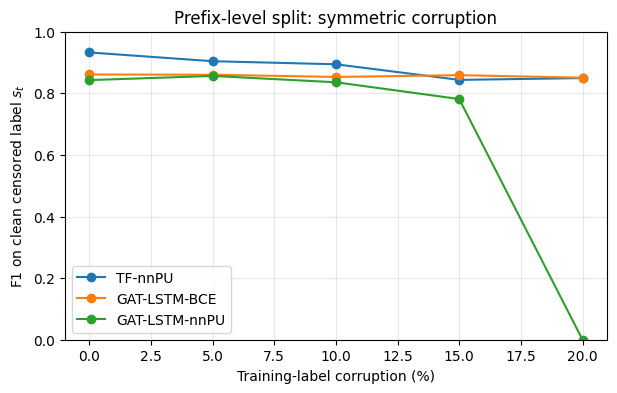

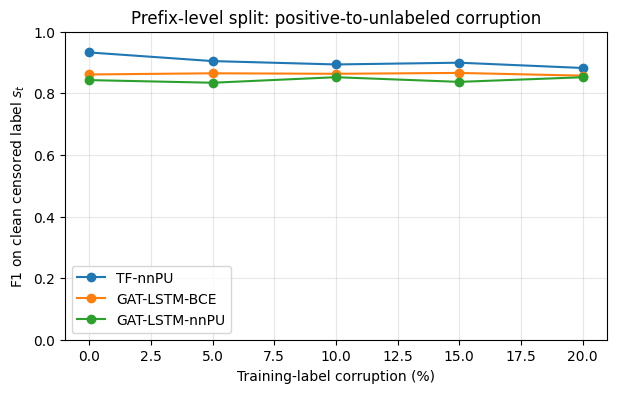

In [31]:
def plot_noise(
    results,
    mode,
    title,
):
    plt.figure(
        figsize=(7, 4)
    )

    clean_rows = results[
        (results["noise_mode"] == "none")
        & (results["noise_rate"] == 0.0)
    ]

    noisy_rows = results[
        results["noise_mode"] == mode
    ]

    for method in [
        "TF-nnPU",
        "GAT-LSTM-BCE",
        "GAT-LSTM-nnPU",
    ]:
        xs = [0]

        ys = [
            float(
                clean_rows[
                    clean_rows["method"]
                    == method
                ]["f1"].iloc[0]
            )
        ]

        for rate in [
            0.05,
            0.10,
            0.15,
            0.20,
        ]:
            row = noisy_rows[
                (noisy_rows["method"] == method)
                & (
                    noisy_rows["noise_rate"]
                    == rate
                )
            ]

            xs.append(
                int(round(rate * 100))
            )

            ys.append(
                float(row["f1"].iloc[0])
            )

        plt.plot(
            xs,
            ys,
            marker="o",
            label=method,
        )

    plt.xlabel(
        "Training-label corruption (%)"
    )

    plt.ylabel(
        "F1 on clean censored label $s_t$"
    )

    plt.ylim(0, 1)
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


plot_noise(
    results,
    "symmetric",
    "Prefix-level split: symmetric corruption",
)

plot_noise(
    results,
    "p_to_u",
    "Prefix-level split: positive-to-unlabeled corruption",
)

# Automatic result summary

In [32]:
print("=" * 76)
print("FULL PREFIX-LEVEL COMPARISON")
print("=" * 76)

for _, row in clean_table.iterrows():
    print(
        f"{row['Method']}: "
        f"P={row['Precision']:.4f}, "
        f"R={row['Recall']:.4f}, "
        f"F1={row['F1']:.4f}"
    )

best_clean = clean.loc[
    clean["f1"].idxmax()
]

print()
print(
    "Best clean:",
    best_clean["method"],
    f"F1={best_clean['f1']:.4f}",
)

for mode in [
    "symmetric",
    "p_to_u",
]:
    rows20 = results[
        (results["noise_mode"] == mode)
        & (results["noise_rate"] == 0.20)
    ]

    best20 = rows20.loc[
        rows20["f1"].idxmax()
    ]

    print(
        f"Best at 20% {mode}:",
        best20["method"],
        f"F1={best20['f1']:.4f}",
    )

print()
print(
    "Validation-scene overlap:",
    f"{100*len(overlap_scenes)/max(1,len(val_scenes)):.2f}%"
)

FULL PREFIX-LEVEL COMPARISON
TF-nnPU: P=0.9562, R=0.9103, F1=0.9327
GAT-LSTM-BCE: P=0.8524, R=0.8702, F1=0.8612
GAT-LSTM-nnPU: P=0.8187, R=0.8686, F1=0.8429

Best clean: TF-nnPU F1=0.9327
Best at 20% symmetric: GAT-LSTM-BCE F1=0.8508
Best at 20% p_to_u: TF-nnPU F1=0.8823

Validation-scene overlap: 100.00%


# Interpretation

The most useful comparison after this run is:

\[
F1_{\text{TF, prefix split}}
\quad \text{vs} \quad
F1_{\text{TF, strict scene split}}.
\]

You previously obtained approximately \(F1=0.82\) under the strict scene-level comparison. If this notebook returns the TF-nnPU toward the original \(0.90\)-range, then the sample-level splitting/exposure is a major reason for the discrepancy.

Because the GAT-LSTM variants use **the exact same split and corruption masks**, this notebook also gives you the complete architecture comparison under the same original-like protocol.